# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [2]:
# loading the netflix dataset from a github link
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv")


In [3]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape


(7787, 12)

### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [6]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [7]:
df.describe()


,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [8]:
# checking missing values before cleaning
df.isnull().sum()


show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [9]:
# dropping rows where director or country is missing
df = df.dropna(subset=["director", "country"])

print(df.shape)
df.isnull().sum()[["director", "country"]]


(5193, 12)


director    0
country     0
dtype: int64

## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [10]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
df["year_added"] = df["date_added"].dt.year

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5193 entries, 1 to 7786
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5193 non-null   object        
 1   type          5193 non-null   object        
 2   title         5193 non-null   object        
 3   director      5193 non-null   object        
 4   cast          4812 non-null   object        
 5   country       5193 non-null   object        
 6   date_added    5193 non-null   datetime64[ns]
 7   release_year  5193 non-null   int64         
 8   rating        5189 non-null   object        
 9   duration      5193 non-null   object        
 10  listed_in     5193 non-null   object        
 11  description   5193 non-null   object        
 12  year_added    5193 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 547.7+ KB


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [11]:
# duration for TV shows is in seasons, not minutes, so we only look at movies here
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = movies["duration"].str.replace(" min", "").astype(int)

top5_longest = movies.sort_values("duration_min", ascending=False).head(5)
top5_longest[["title", "country", "release_year", "duration"]]


,title,country,release_year,duration
6850,The School of Mischief,Egypt,1973,253 min
4490,No Longer kids,Egypt,1979,237 min
5376,Sangam,India,1964,228 min
3521,Lagaan,India,2001,224 min
3195,Jodhaa Akbar,India,2008,214 min


## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [12]:
df["type"].value_counts()


type
Movie      5024
TV Show     169
Name: count, dtype: int64

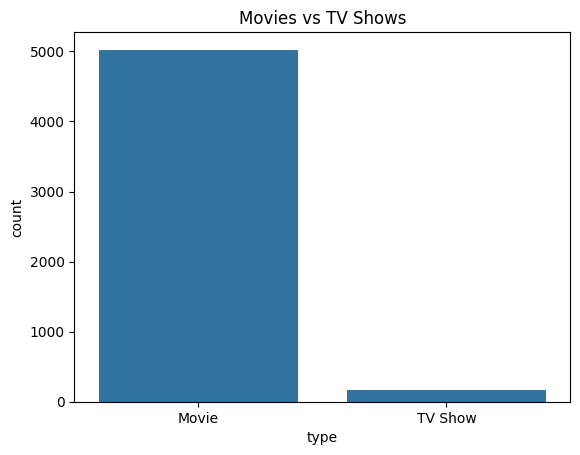

In [13]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows")
plt.show()

# Movies make up a much bigger share of the catalogue than TV Shows.


## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [14]:
top_countries = df["country"].value_counts().head(5)
top_countries


country
United States     1838
India              848
United Kingdom     201
Canada             115
Spain               97
Name: count, dtype: int64

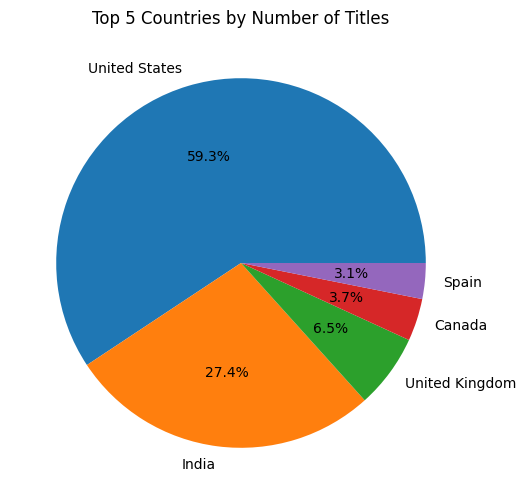

In [15]:
plt.figure(figsize=(6, 6))
plt.pie(top_countries, labels=top_countries.index, autopct="%1.1f%%")
plt.title("Top 5 Countries by Number of Titles")
plt.show()


## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [16]:
# a title can belong to more than one genre, so we split listed_in and explode it into separate rows
genre_df = df.copy()
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")
genre_df = genre_df.explode("listed_in")

genre_leader = genre_df.groupby("listed_in")["country"].agg(lambda x: x.value_counts().index[0])

for genre, country in genre_leader.items():
    print(genre, "->", country)


Action & Adventure -> United States
Anime Features -> Japan
Anime Series -> Japan
British TV Shows -> United Kingdom
Children & Family Movies -> United States
Classic & Cult TV -> United Kingdom
Classic Movies -> United States
Comedies -> United States
Crime TV Shows -> United States
Cult Movies -> United States
Documentaries -> United States
Docuseries -> United States
Dramas -> India
Faith & Spirituality -> United States
Horror Movies -> United States
Independent Movies -> United States
International Movies -> India
International TV Shows -> South Korea
Kids' TV -> United Kingdom
Korean TV Shows -> South Korea
LGBTQ Movies -> United States
Movies -> United States
Music & Musicals -> United States
Reality TV -> Brazil
Romantic Movies -> United States
Romantic TV Shows -> South Korea
Sci-Fi & Fantasy -> United States
Science & Nature TV -> United States
Spanish-Language TV Shows -> Spain
Sports Movies -> United States
Stand-Up Comedy -> United States
Stand-Up Comedy & Talk Shows -> Uni

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

In [17]:
year_counts = df.groupby("year_added").size()
busiest_year = year_counts.idxmax()

print("Netflix added the most titles in", busiest_year)
year_counts


Netflix added the most titles in 2019


year_added
2008       1
2009       2
2010       1
2011      13
2012       3
2013       7
2014      18
2015      56
2016     245
2017     858
2018    1191
2019    1424
2020    1295
2021      79
dtype: int64

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

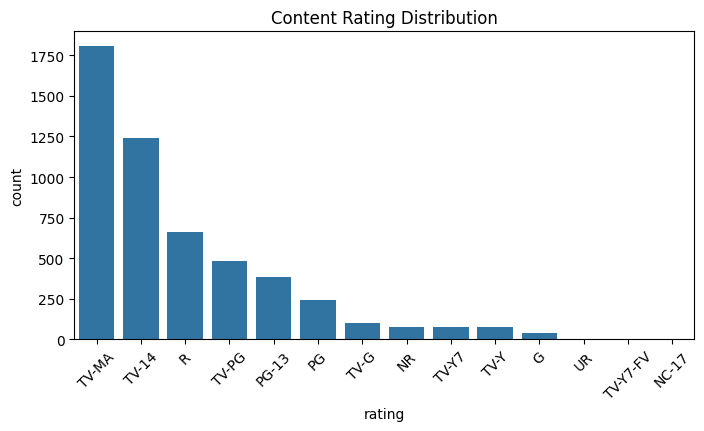

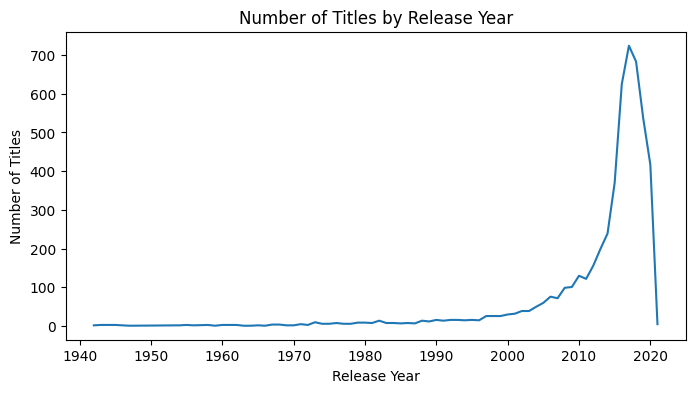

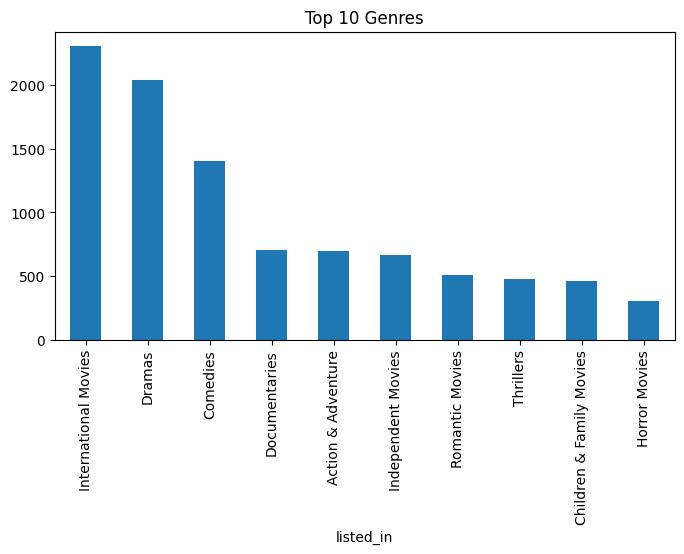

In [18]:
# Extra plot 1: content rating distribution
plt.figure(figsize=(8, 4))
sns.countplot(x="rating", data=df, order=df["rating"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Content Rating Distribution")
plt.show()
# Most titles are rated TV-MA or TV-14, so the catalogue leans towards mature audiences.

# Extra plot 2: number of titles by release year
plt.figure(figsize=(8, 4))
df["release_year"].value_counts().sort_index().plot(kind="line")
plt.title("Number of Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()
# The number of titles jumps up a lot after 2010, so most of the catalogue is fairly recent content.

# Extra plot 3: top 10 genres
plt.figure(figsize=(8, 4))
genre_df["listed_in"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()
# Dramas and comedies are the most common genres in the catalogue.
